# A Single Heatmap

A single heatmap is the most used approach for visualizing data. Although the main strength of **complexheatmap** is visualizing a list of heatmaps in parallel, a well-configured single heatmap is the basic building block.

This tutorial covers: basic heatmap creation, color mapping with `color_ramp2`, clustering options, row/column splitting (k-means and manual), titles, ordering, `cell_fun`/`layer_fun`, rasterization, and NA handling.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import Heatmap, color_ramp2, ht_opt
import grid_py as gp

## Generating a demo matrix

First let's generate a random matrix where there are three groups in the columns and three groups in the rows, then shuffle the rows and columns.

In [2]:
np.random.seed(123)
nr1, nr2, nr3 = 4, 8, 6
nc1, nc2, nc3 = 6, 8, 10
nr = nr1 + nr2 + nr3
nc = nc1 + nc2 + nc3

mat = np.hstack([
    np.vstack([np.random.normal(1,   0.5, (nr1, nc1)),
               np.random.normal(0,   0.5, (nr2, nc1)),
               np.random.normal(0,   0.5, (nr3, nc1))]),
    np.vstack([np.random.normal(0,   0.5, (nr1, nc2)),
               np.random.normal(1,   0.5, (nr2, nc2)),
               np.random.normal(0,   0.5, (nr3, nc2))]),
    np.vstack([np.random.normal(0.5, 0.5, (nr1, nc3)),
               np.random.normal(0.5, 0.5, (nr2, nc3)),
               np.random.normal(1,   0.5, (nr3, nc3))])
])

# Shuffle rows and columns
row_idx = np.random.permutation(nr)
col_idx = np.random.permutation(nc)
mat = mat[row_idx][:, col_idx]

# Create a DataFrame with row/column names
mat = pd.DataFrame(mat,
    index=[f"row{i+1}" for i in range(nr)],
    columns=[f"column{i+1}" for i in range(nc)])

print(f"Matrix shape: {mat.shape}")
mat.head()

Matrix shape: (18, 24)


,column1,column2,column3,column4,column5,column6,column7,column8,column9,column10,...,column15,column16,column17,column18,column19,column20,column21,column22,column23,column24
row1,-0.633676,0.034394,0.090518,0.588931,0.515557,0.161288,1.191435,-0.618677,-0.217083,0.667072,...,0.376934,1.017970,0.754514,0.345417,0.575103,1.425051,1.488406,0.124465,-0.123408,0.995670
row2,0.680549,-0.281962,0.778009,0.782824,2.093393,-0.498661,-0.125595,0.804345,-0.550022,-0.210106,...,0.249870,0.066752,1.204185,0.195645,1.745695,0.166596,0.165191,1.132313,0.237174,-0.160301
row3,0.344111,0.903018,-0.439768,0.141814,-0.863835,1.067013,0.091166,1.276928,1.352237,0.165176,...,0.928412,0.493198,-0.002484,0.820109,0.001423,0.843100,0.434778,0.375672,1.010158,1.187495
row4,-0.318876,0.893960,0.453553,-0.714340,-0.430877,1.228135,0.882527,0.588284,1.772272,0.707847,...,1.166382,0.580272,0.977916,0.061193,-0.626940,0.909880,0.847894,1.437900,1.278274,-0.461858
row5,-0.681736,0.139831,0.189700,-0.189588,-0.988944,0.124985,0.309824,0.516240,-0.487154,0.950620,...,-0.099556,0.735006,0.887844,1.240937,-0.542284,-0.221538,0.145504,1.364268,0.145437,1.507152


## Basic Heatmap

The simplest heatmap call draws dendrograms, row/column names, and a legend. The default color scheme maps the minimum through mean to maximum as blue-white-red.

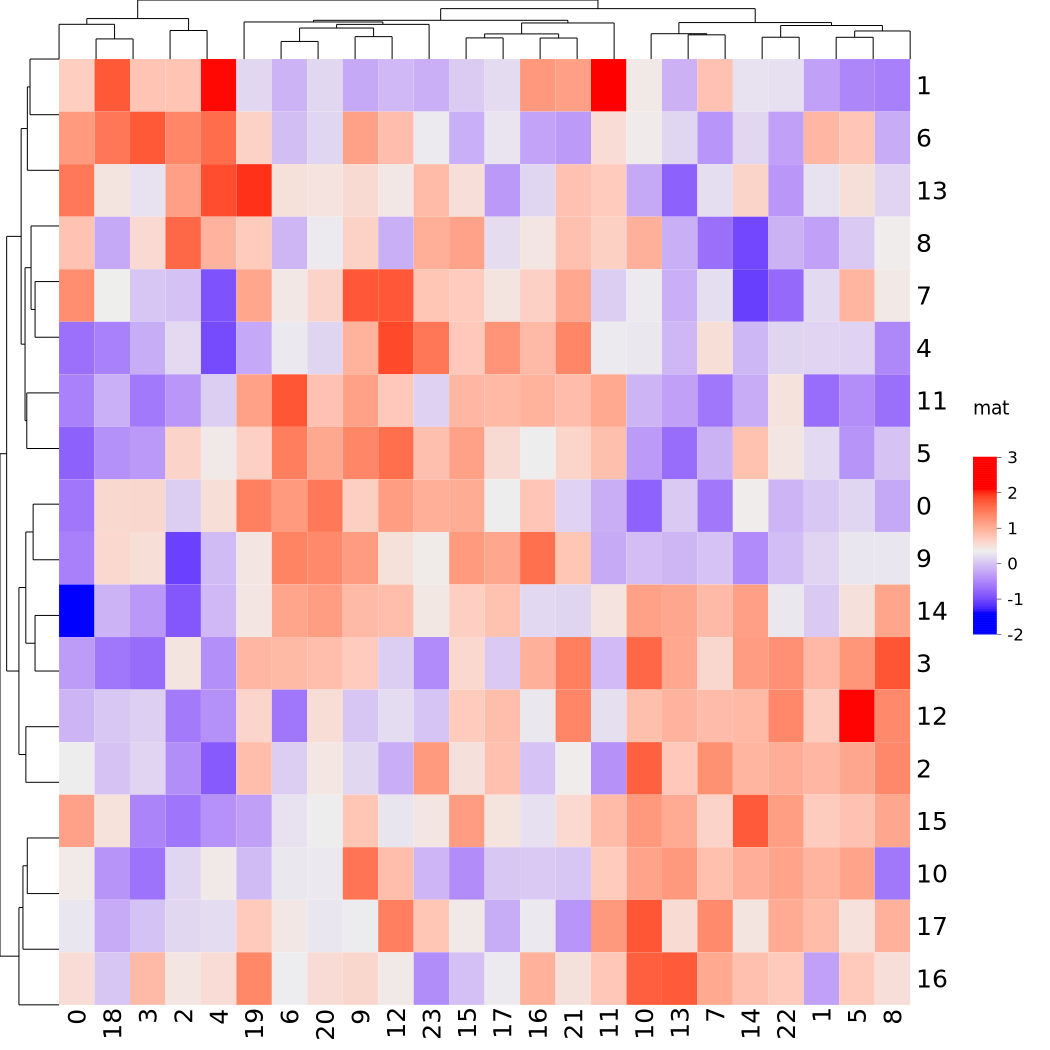

In [3]:
ht = Heatmap(mat.values, name="mat")
ht.draw()

## Colors with `color_ramp2`

To control the color mapping, use `color_ramp2` which linearly interpolates colors in LAB color space. This ensures:
- The mapping is centered where you want it (e.g., 0 = white)
- Outliers do not distort the color scale
- Multiple heatmaps are comparable when sharing the same color function

In [4]:
col_fun = color_ramp2([-2, 0, 2], ["green", "white", "red"])

# Verify the mapping at key points
print(f"col_fun(-2) = {col_fun(-2)}")
print(f"col_fun(0)  = {col_fun(0)}")
print(f"col_fun(2)  = {col_fun(2)}")

col_fun(-2) = #008000
col_fun(0)  = #FFFFFF
col_fun(2)  = #FF0000


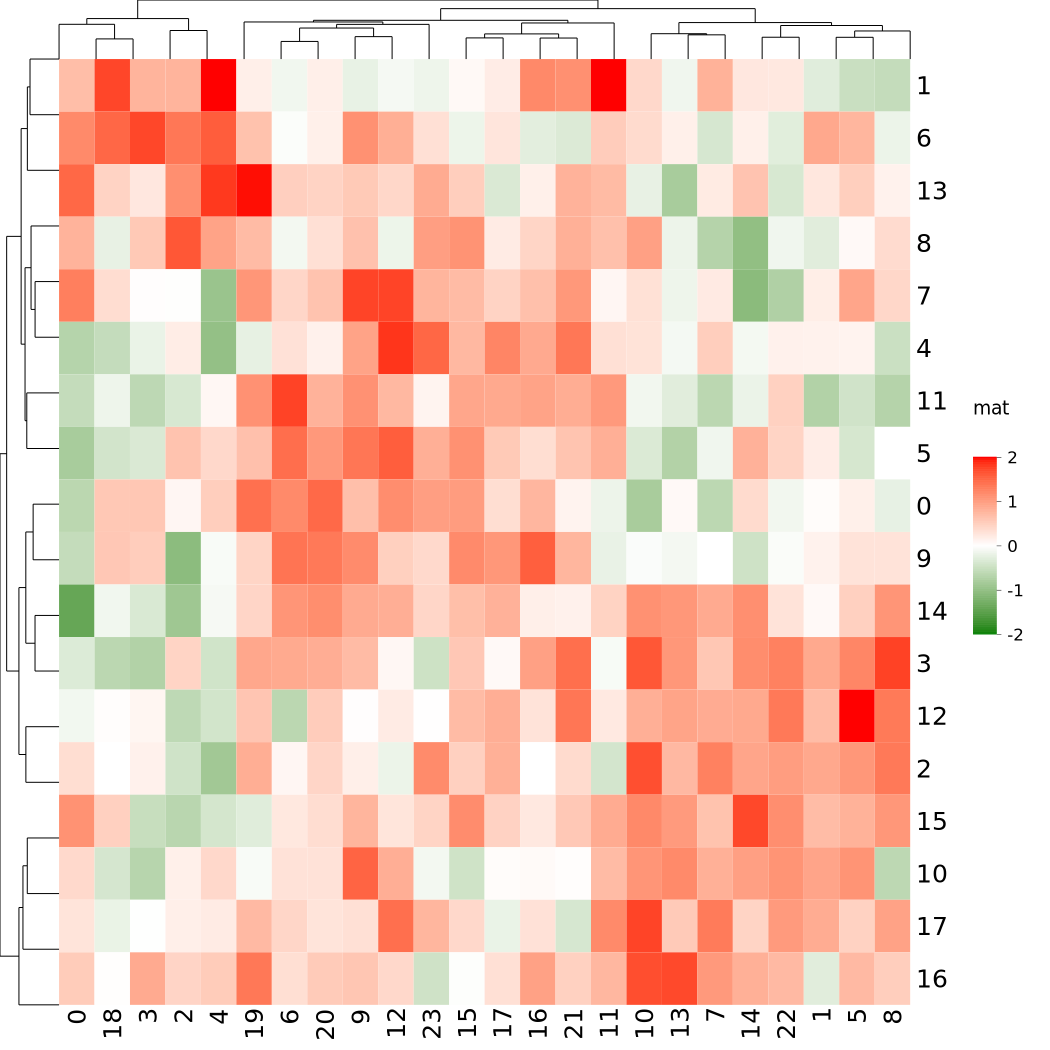

In [5]:
ht = Heatmap(mat.values, name="mat", col=col_fun)
ht.draw()

Because the color function is fixed, outliers do not affect the color mapping -- only the clustering is affected.

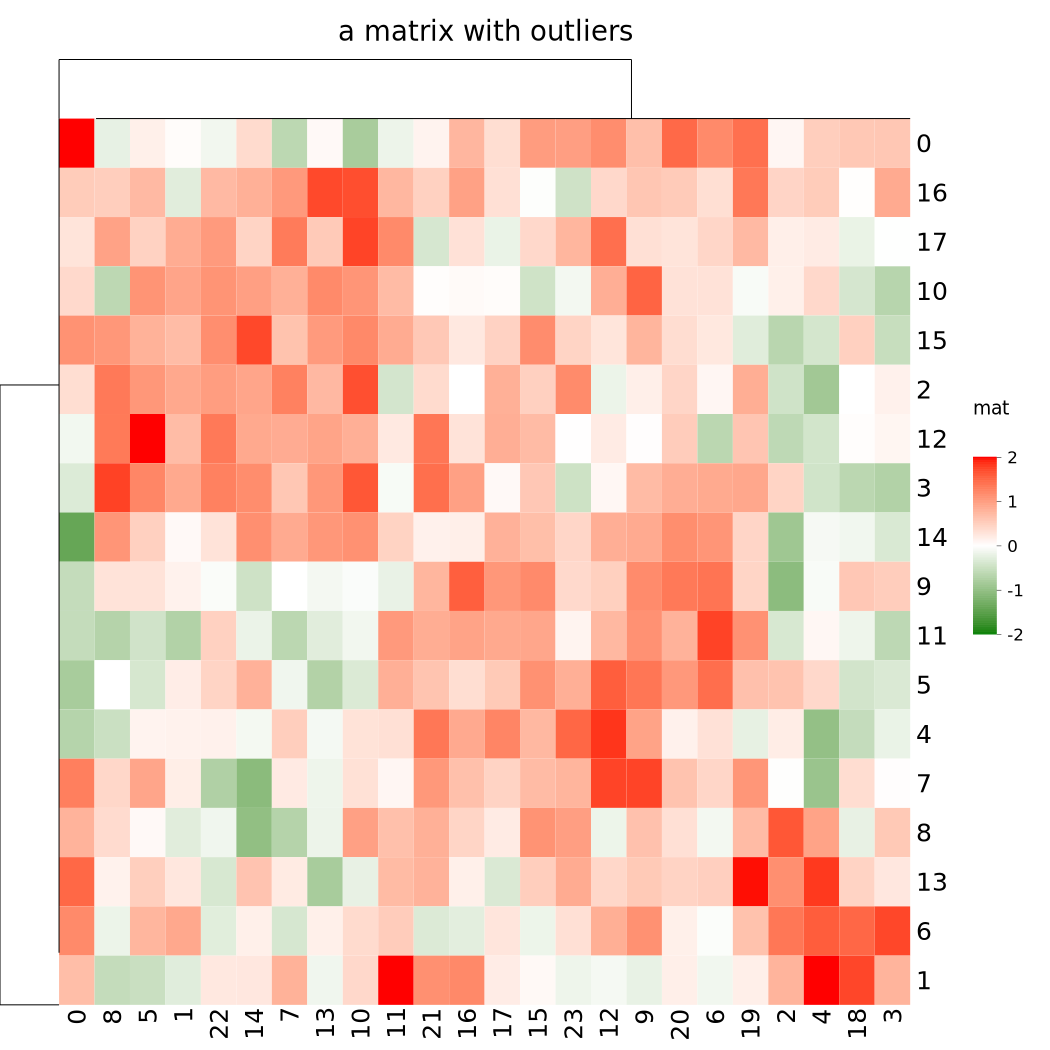

In [6]:
mat2 = mat.values.copy()
mat2[0, 0] = 100000
ht = Heatmap(mat2, name="mat", col=col_fun,
             column_title="a matrix with outliers")
ht.draw()

## NA Handling

`NA` (represented as `np.nan` in Python) is allowed in the matrix. Control the color of missing values with `na_col`.

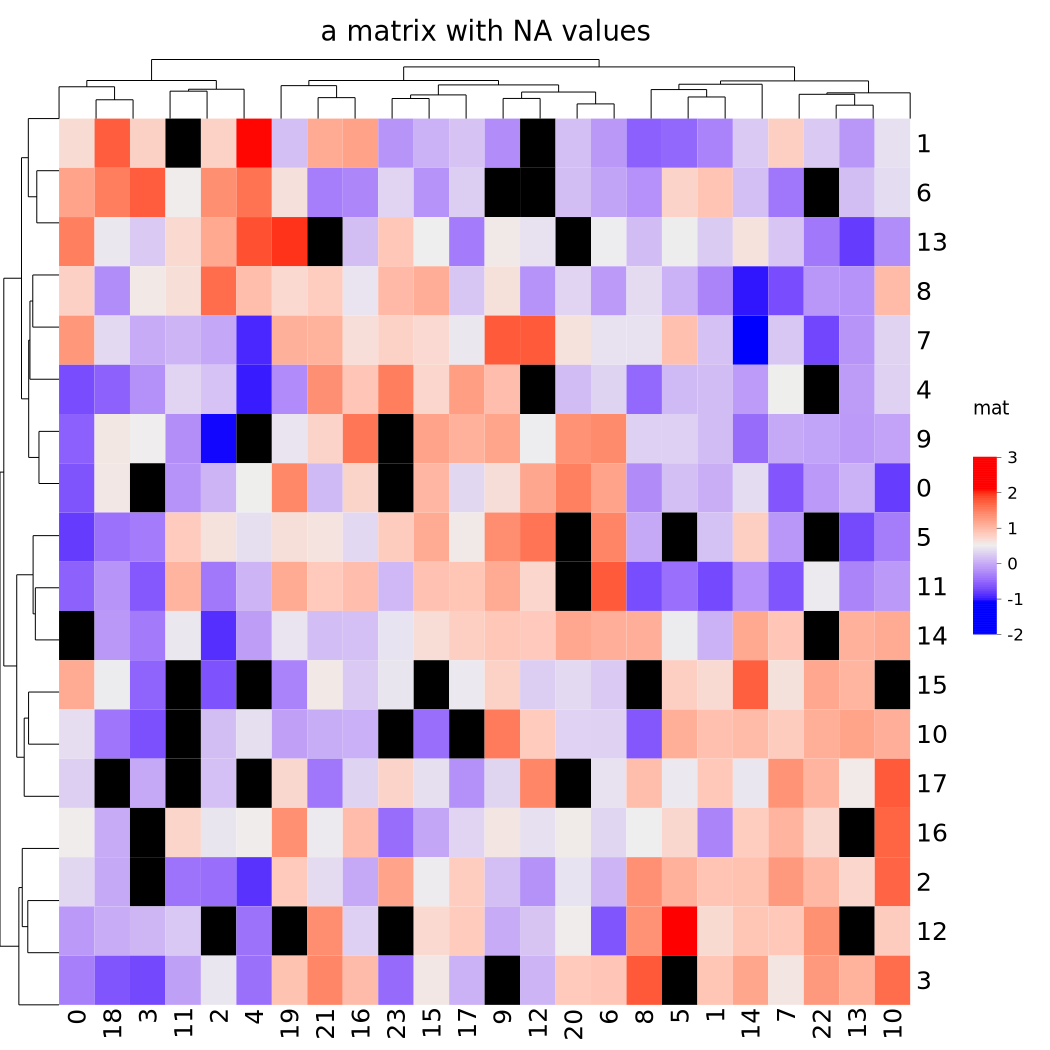

In [7]:
mat_with_na = mat.values.copy()
na_mask = np.random.choice([True, False], size=mat_with_na.shape, p=[0.1, 0.9])
mat_with_na[na_mask] = np.nan

ht = Heatmap(mat_with_na, name="mat", na_col="black",
             column_title="a matrix with NA values")
ht.draw()

## Titles

Row and column titles can be placed on any side. Graphics parameters are controlled through `gpar`-style dicts.

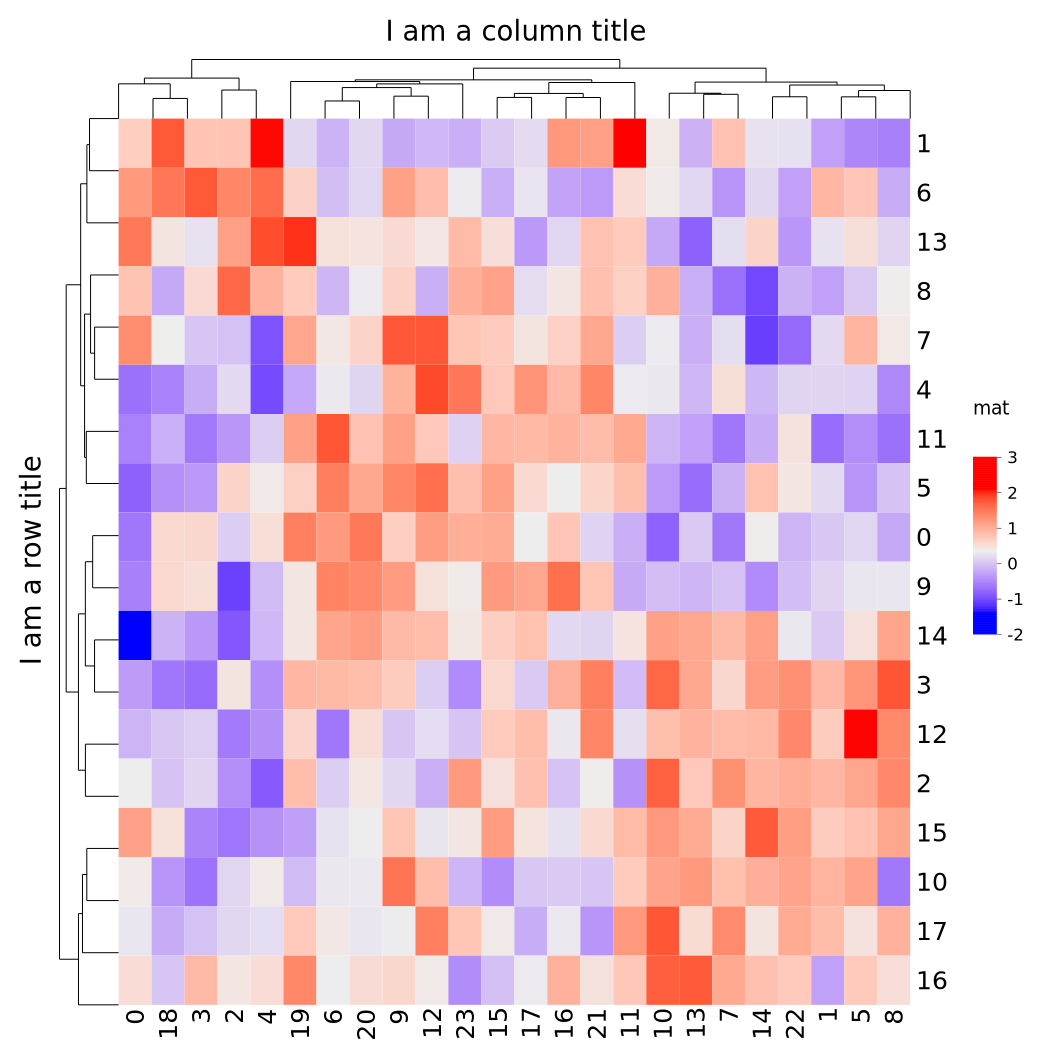

In [8]:
ht = Heatmap(mat.values, name="mat",
             column_title="I am a column title",
             row_title="I am a row title")
ht.draw()

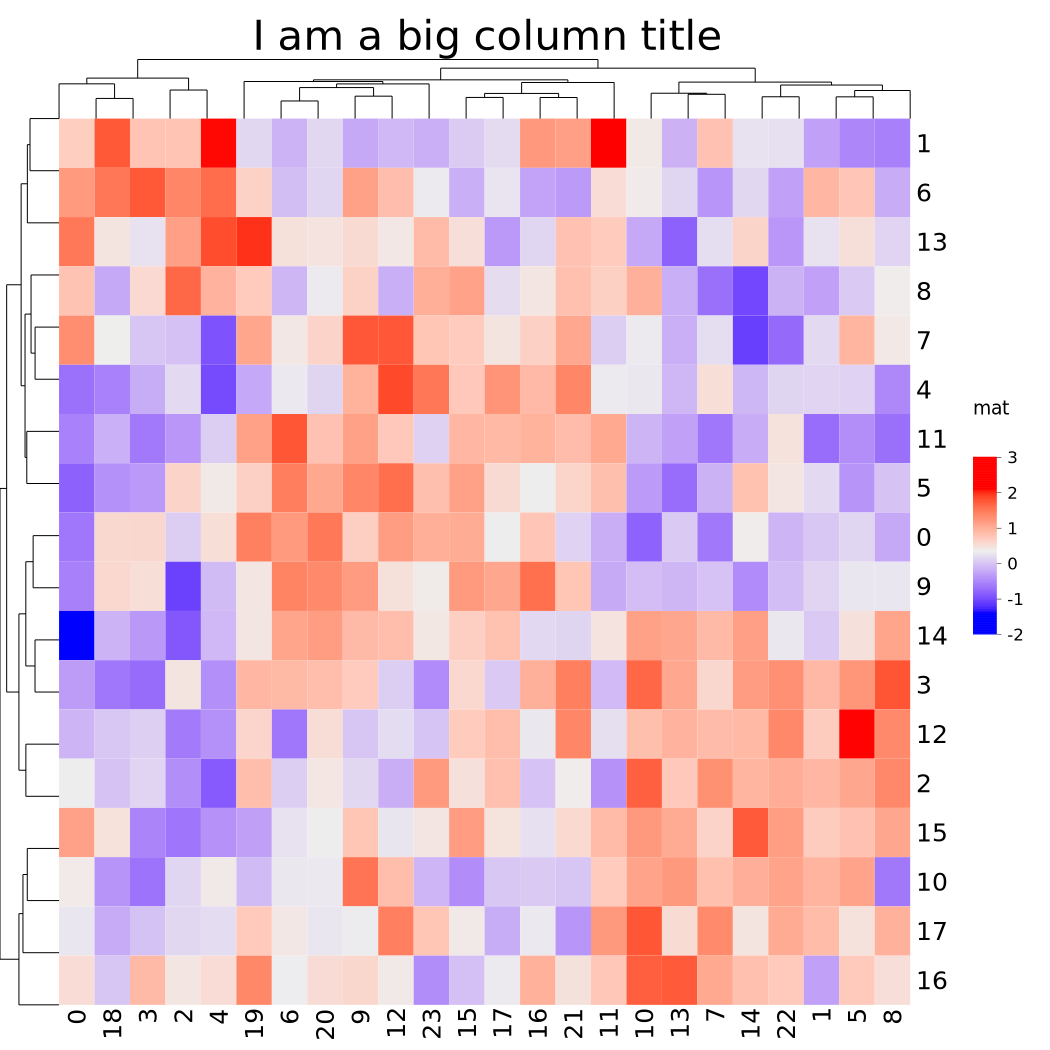

In [9]:
ht = Heatmap(mat.values, name="mat",
             column_title="I am a big column title",
             column_title_gp={"fontsize": 20, "fontface": "bold"})
ht.draw()

## Clustering

Hierarchical clustering is the key component of heatmap visualization. You can:
- Turn clustering on/off (`cluster_rows`, `cluster_columns`)
- Control dendrogram visibility and side
- Specify distance methods (`clustering_distance_rows`)
- Specify linkage methods (`clustering_method_rows`)

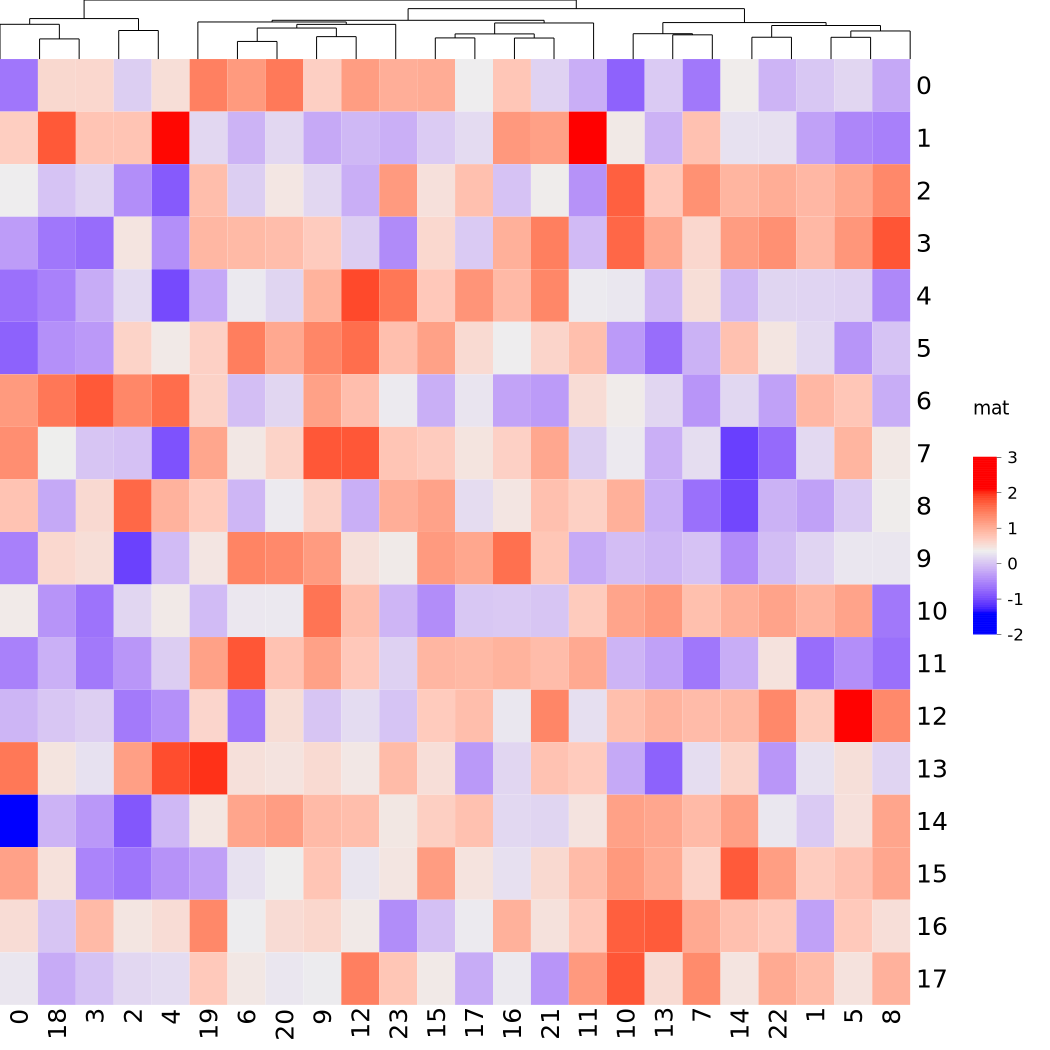

In [10]:
# Turn off row clustering
ht = Heatmap(mat.values, name="mat", cluster_rows=False)
ht.draw()

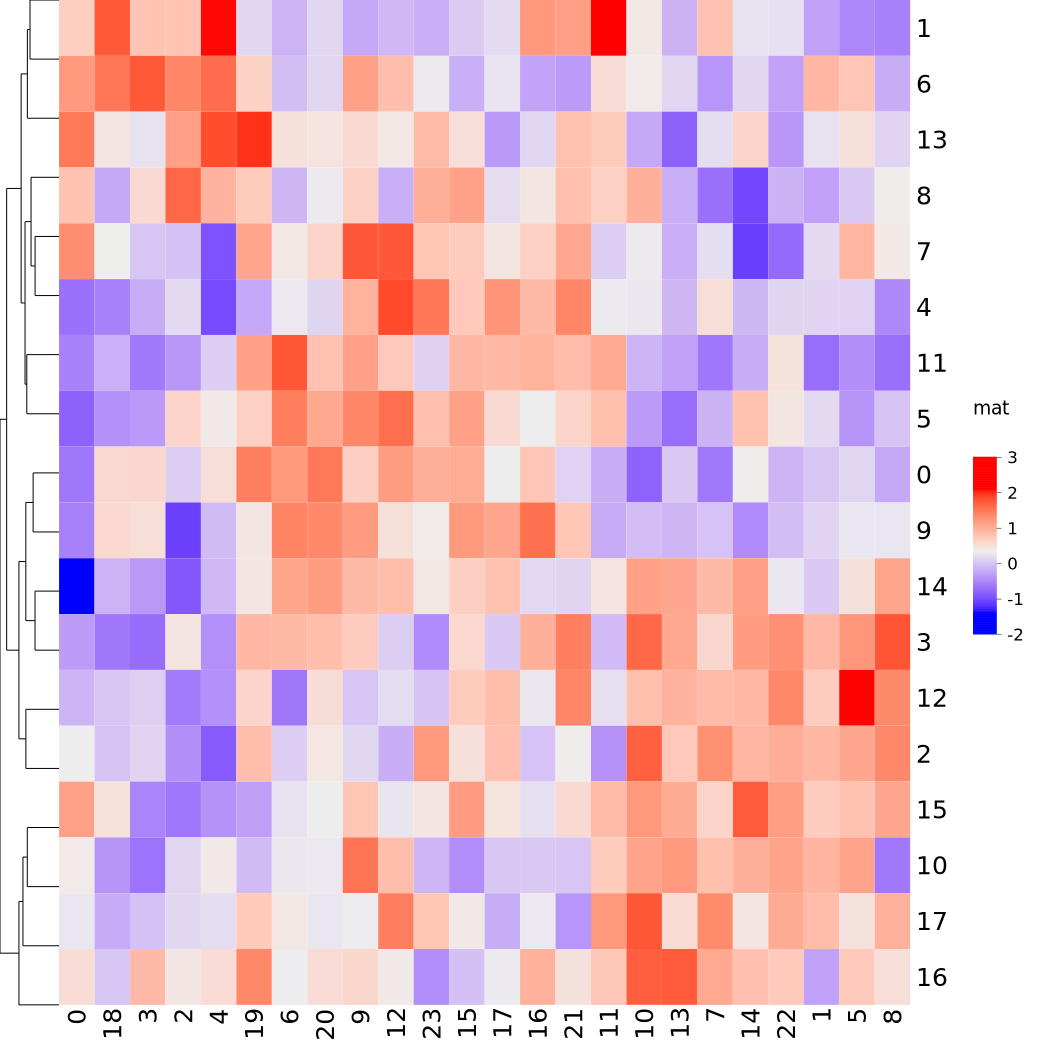

In [11]:
# Hide column dendrogram
ht = Heatmap(mat.values, name="mat", show_column_dend=False)
ht.draw()

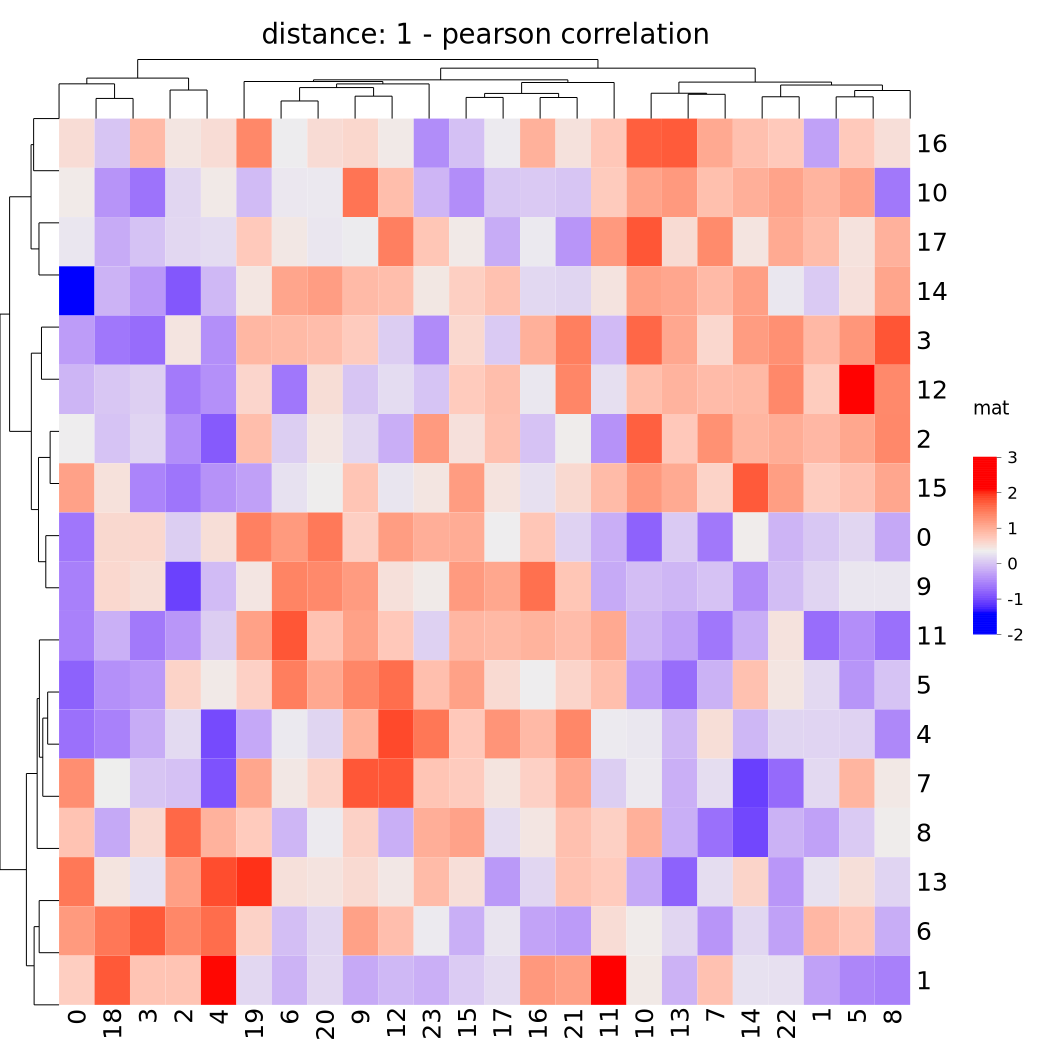

In [12]:
# Use pearson correlation distance
ht = Heatmap(mat.values, name="mat",
             clustering_distance_rows="pearson",
             column_title="distance: 1 - pearson correlation")
ht.draw()

## Row and Column Order

You can manually set the order of rows/columns. When `row_order` is set, row clustering is turned off by default.

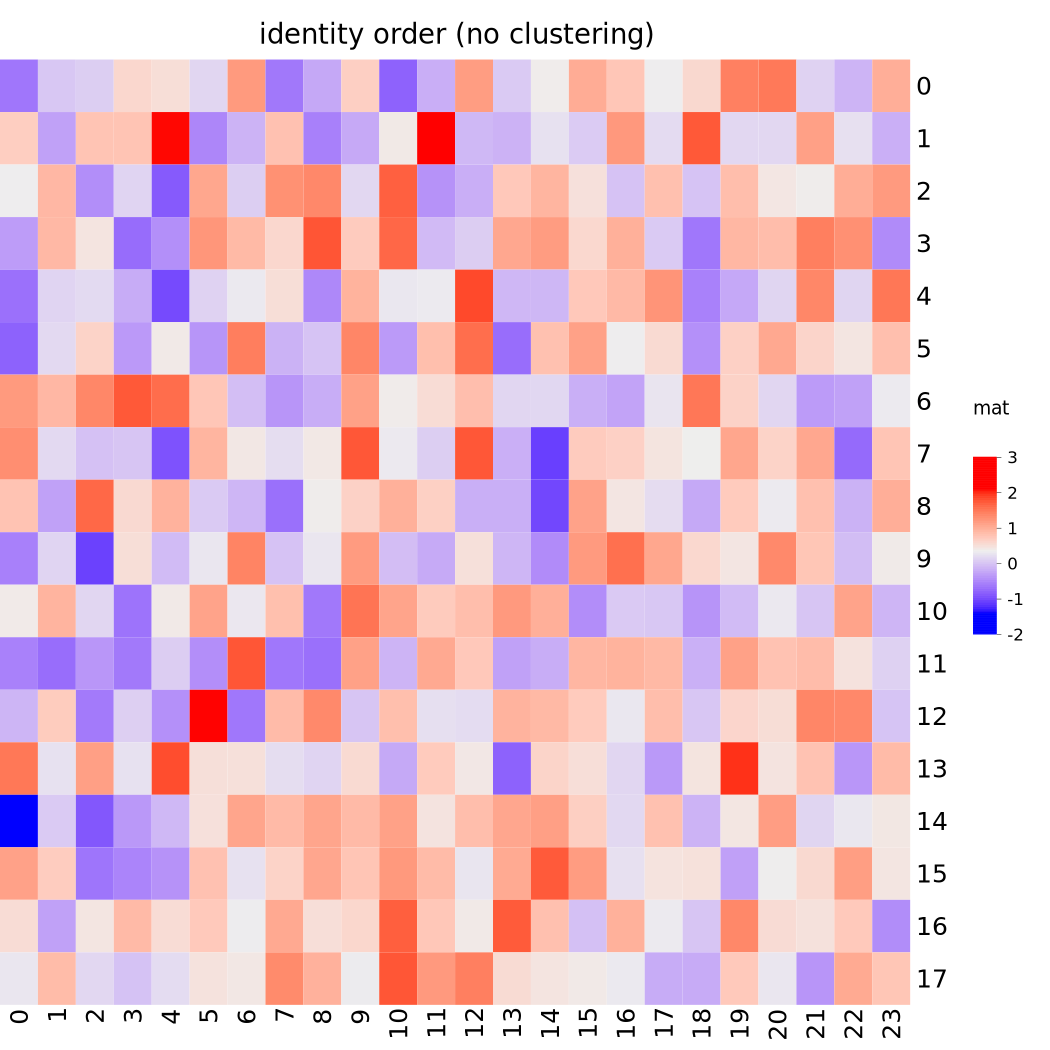

In [13]:
ht = Heatmap(mat.values, name="mat",
             row_order=list(range(nr)),
             column_order=list(range(nc)),
             column_title="identity order (no clustering)")
ht.draw()

Verify that when clustering is disabled, the row/column order is identity:

In [14]:
ht_no = Heatmap(mat.values, name="no_clust",
                cluster_rows=False, cluster_columns=False)
ht_no.make_layout()
ro = ht_no.row_order_list()[0]
co = ht_no.column_order_list()[0]
print(f"Row order is identity:    {np.array_equal(ro, np.arange(nr))}")
print(f"Column order is identity: {np.array_equal(co, np.arange(nc))}")

Row order is identity:    True
Column order is identity: True


## Heatmap Splitting

One major advantage of ComplexHeatmap is splitting the heatmap by rows and columns to better group features.

### Split by k-means

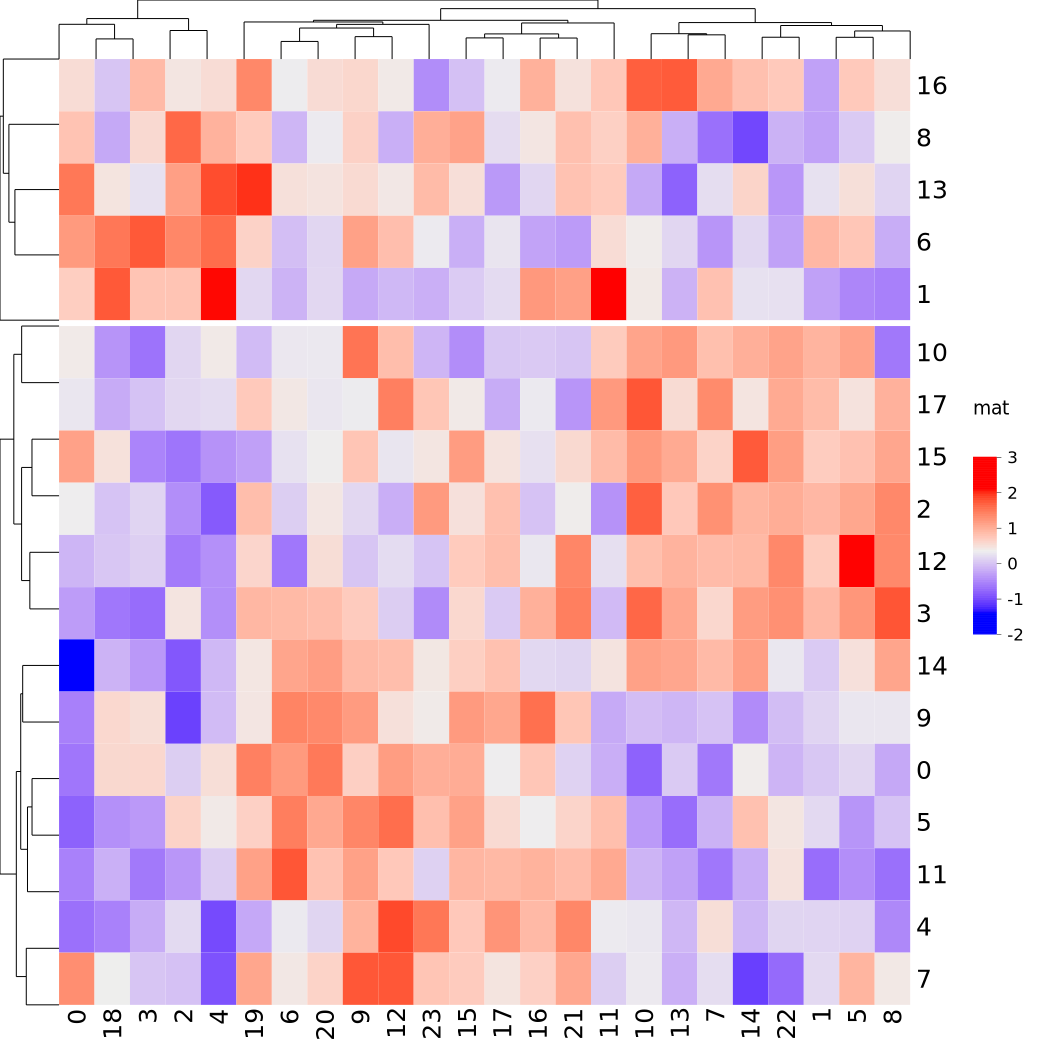

In [15]:
np.random.seed(42)
ht = Heatmap(mat.values, name="mat", row_km=2)
ht.draw()

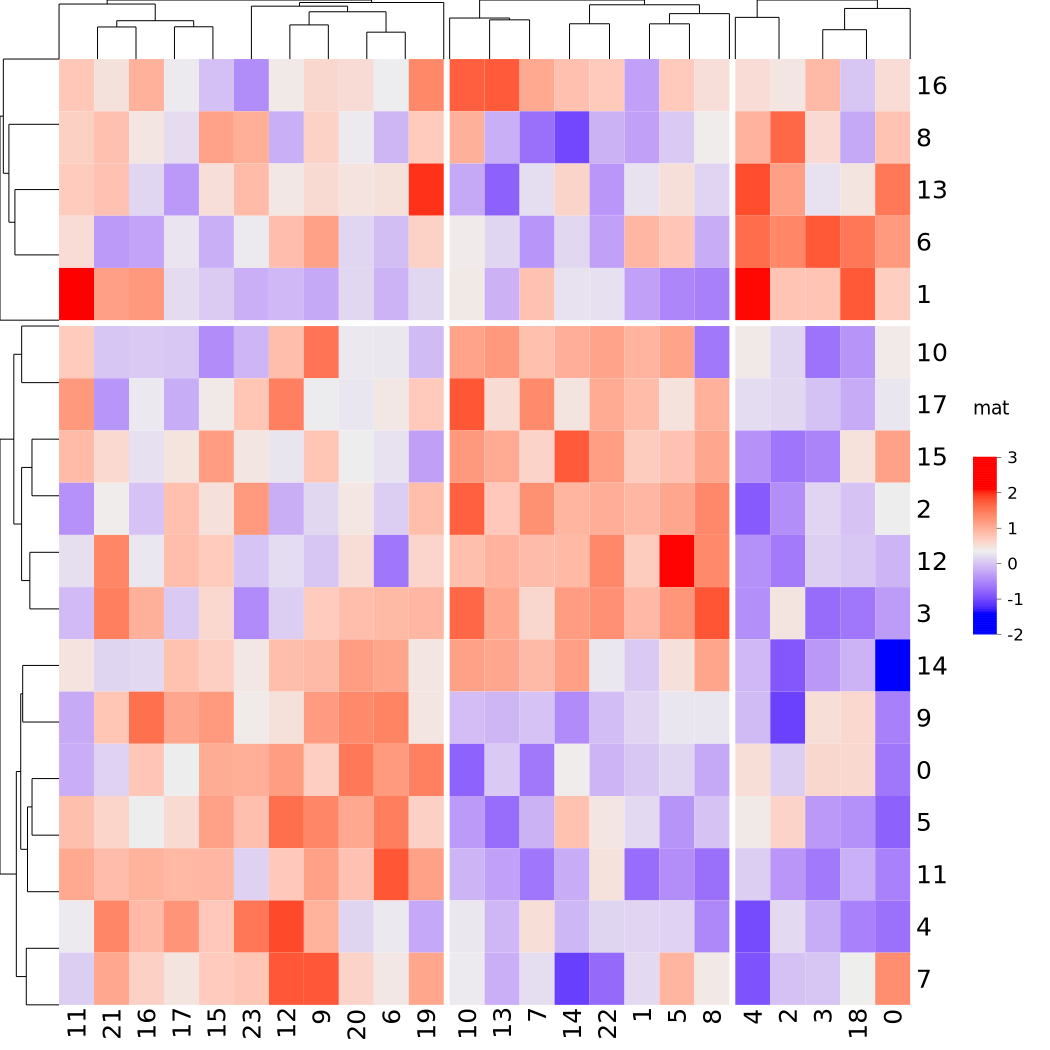

In [16]:
np.random.seed(42)
ht = Heatmap(mat.values, name="mat", row_km=2, column_km=3)
ht.draw()

We can verify that k-means splitting produces the expected number of slices:

In [17]:
np.random.seed(42)
ht_km = Heatmap(mat.values, name="km_test", row_km=3)
ht_km.make_layout()
n_slices = len(ht_km.row_order_list())
print(f"row_km=3 produced {n_slices} row slices")

row_km=3 produced 3 row slices


### Split by categorical variable

`row_split` / `column_split` can be set to a categorical vector.

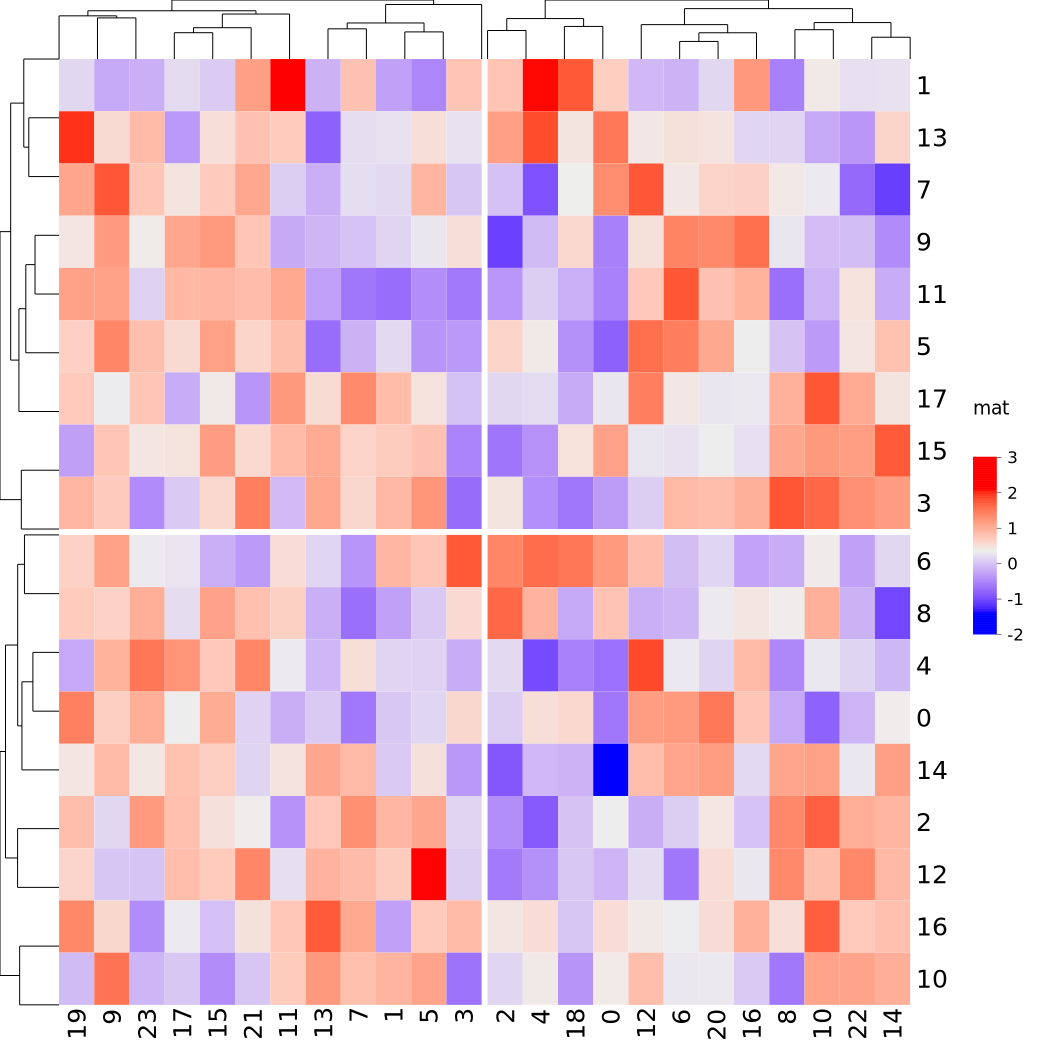

In [18]:
row_split = np.array(["A", "B"] * 9)
col_split = np.array(["C", "D"] * 12)

ht = Heatmap(mat.values, name="mat",
             row_split=row_split,
             column_split=col_split)
ht.draw()

In [19]:
# Verify column_split produces 2 slices
col_split_ab = np.array(["A"] * 5 + ["B"] * 5)
small_mat = np.random.randn(20, 10)
ht_cs = Heatmap(small_mat, name="cs_test", column_split=col_split_ab)
ht_cs.make_layout()
print(f"column_split produced {len(ht_cs.column_order_list())} slices")

column_split produced 2 slices


## Dimension Names

You can control the side, visibility, and style of row/column names.

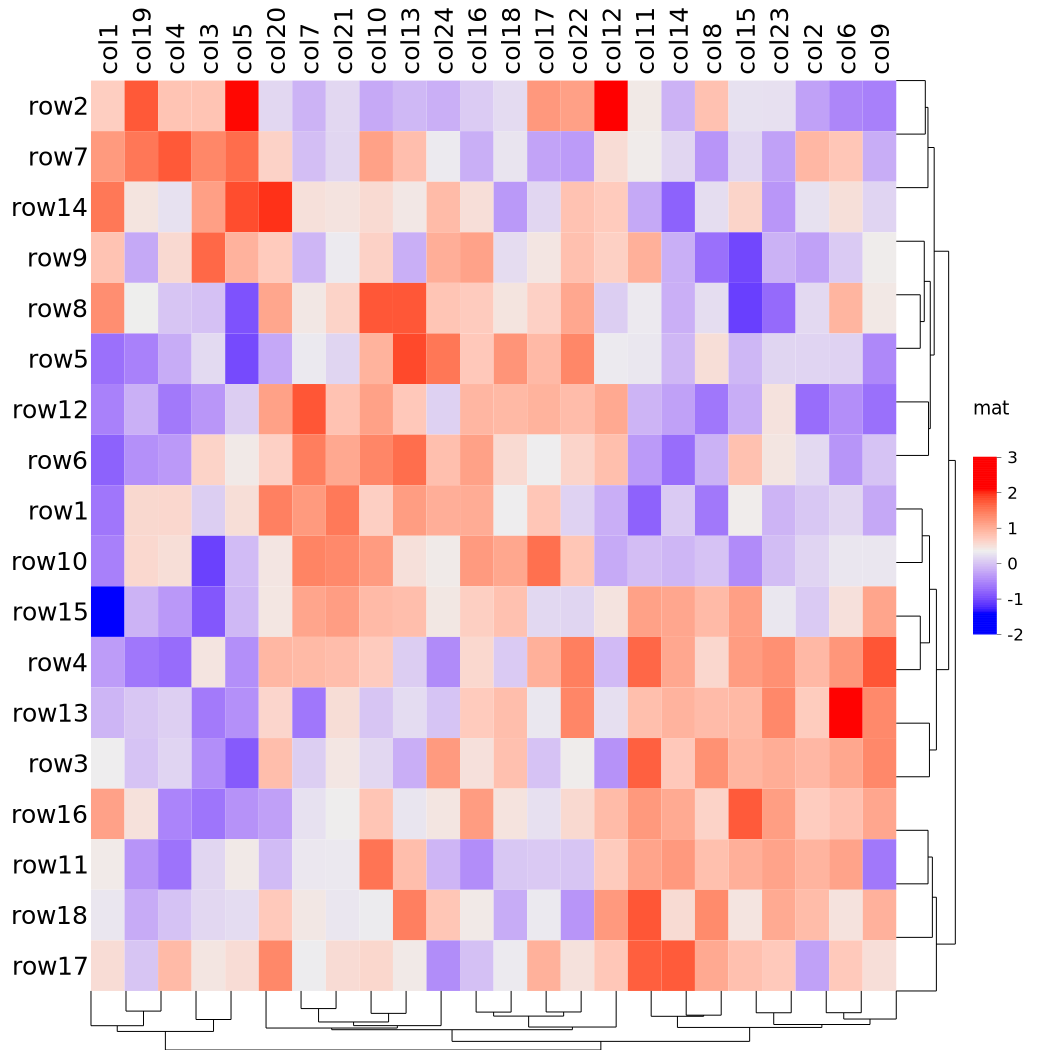

In [20]:
ht = Heatmap(mat.values, name="mat",
             row_names_side="left",
             row_dend_side="right",
             column_names_side="top",
             column_dend_side="bottom",
             row_labels=[f"row{i+1}" for i in range(nr)],
             column_labels=[f"col{i+1}" for i in range(nc)])
ht.draw()

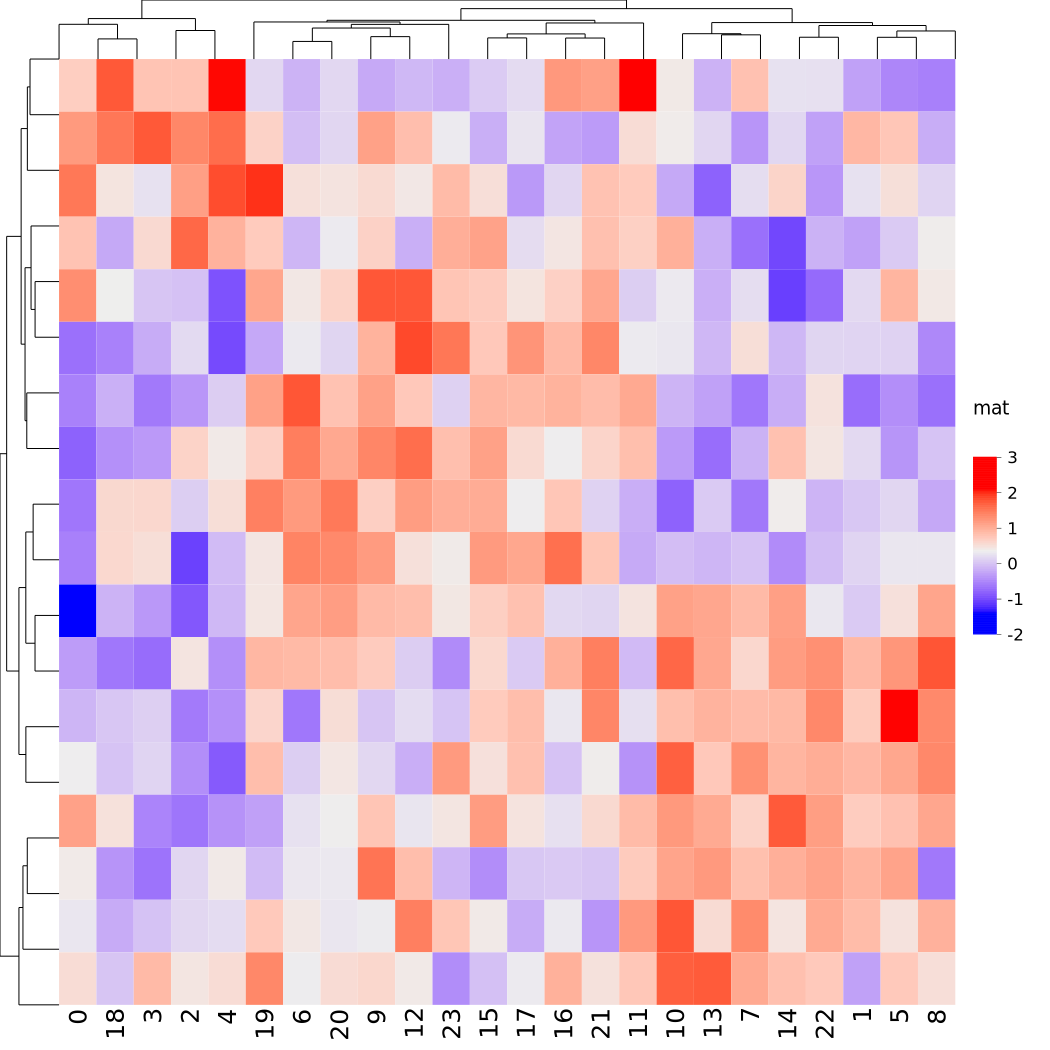

In [21]:
# Hide row names
ht = Heatmap(mat.values, name="mat", show_row_names=False)
ht.draw()

## Customize the Heatmap Body: `cell_fun` and `layer_fun`

`cell_fun` adds custom graphics to each cell. It receives `(j, i, x, y, width, height, fill)` -- column index, row index, center x, center y, cell width, cell height, and the fill color.

`layer_fun` is the vectorized (faster) equivalent that processes an entire slice at once.

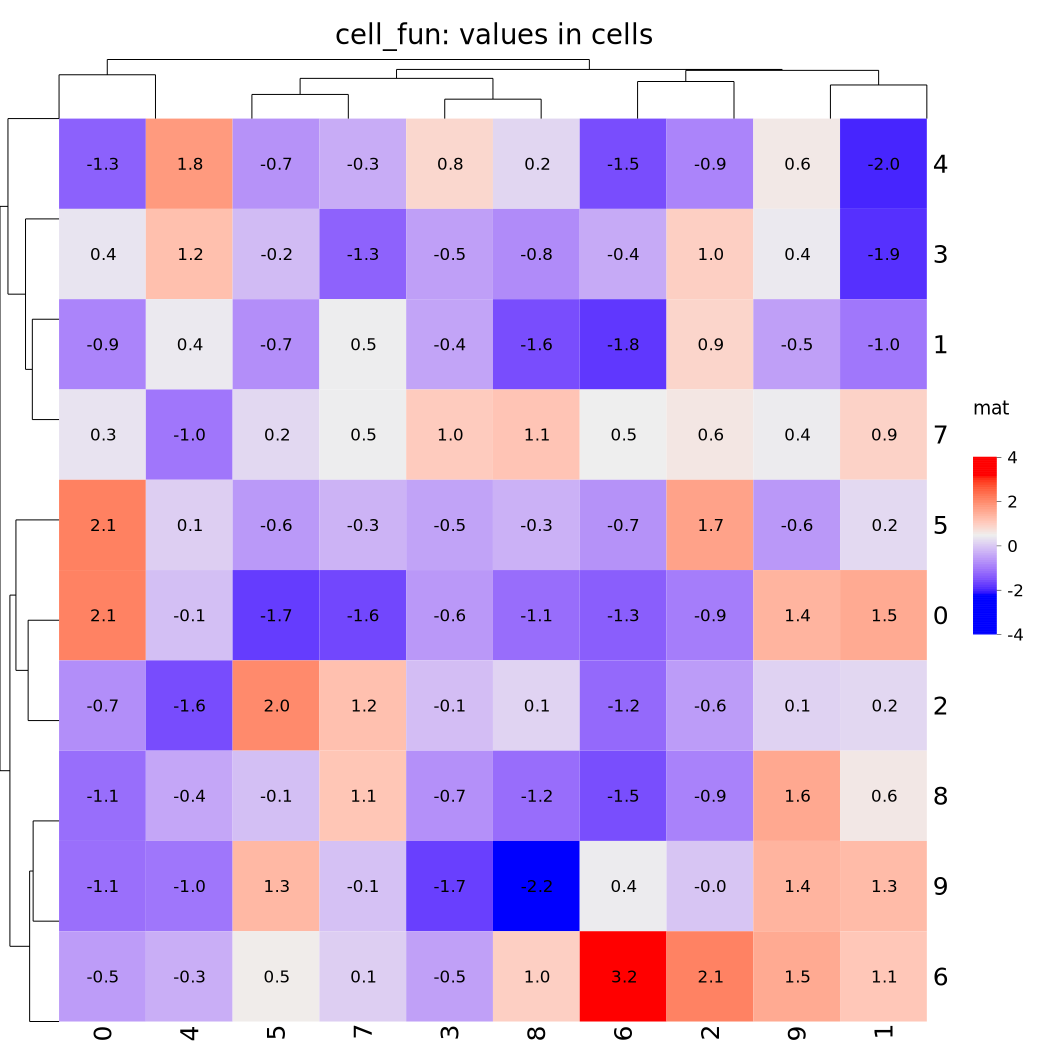

In [22]:
small = np.random.randn(10, 10)

# cell_fun: add text values to each cell
def my_cell_fun(j, i, x, y, w, h, fill):
    gp.grid_text(f"{small[i, j]:.1f}", x, y,
                 gp={"fontsize": 8})

ht = Heatmap(small, name="mat",
             cell_fun=my_cell_fun,
             column_title="cell_fun: values in cells")
ht.draw()

## Heatmap as Raster Image

For very large matrices, rasterization converts the vector graphic into a pixel image, reducing file size. Use `use_raster=True` to enable it. A `raster_quality` factor controls the resolution.

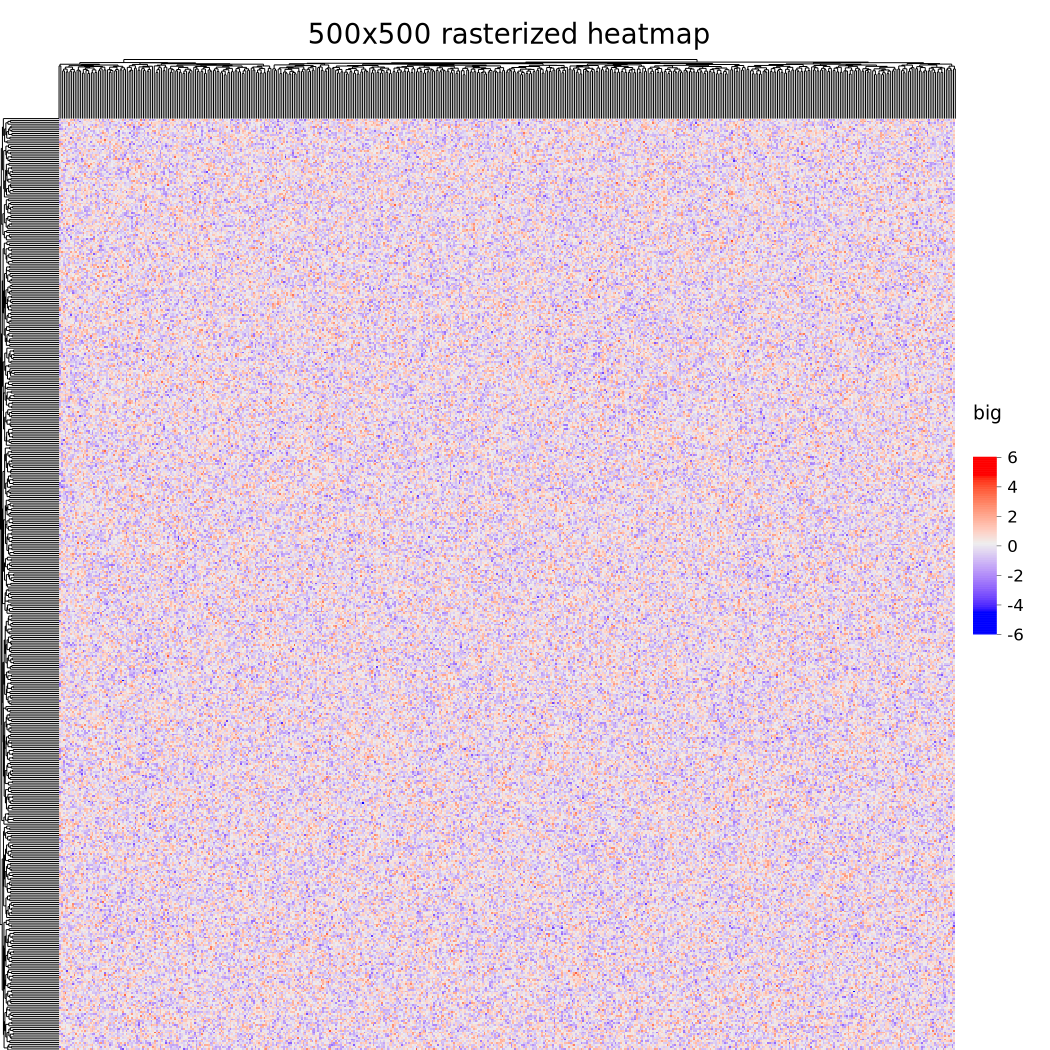

In [23]:
large_mat = np.random.randn(500, 500)
ht = Heatmap(large_mat, name="big",
             use_raster=True,
             raster_quality=2,
             show_row_names=False,
             show_column_names=False,
             column_title="500x500 rasterized heatmap")
ht.draw()

## Heatmap Border and Cell Border

`border` / `border_gp` controls the global border of the heatmap body, while `rect_gp` controls the border of each cell.

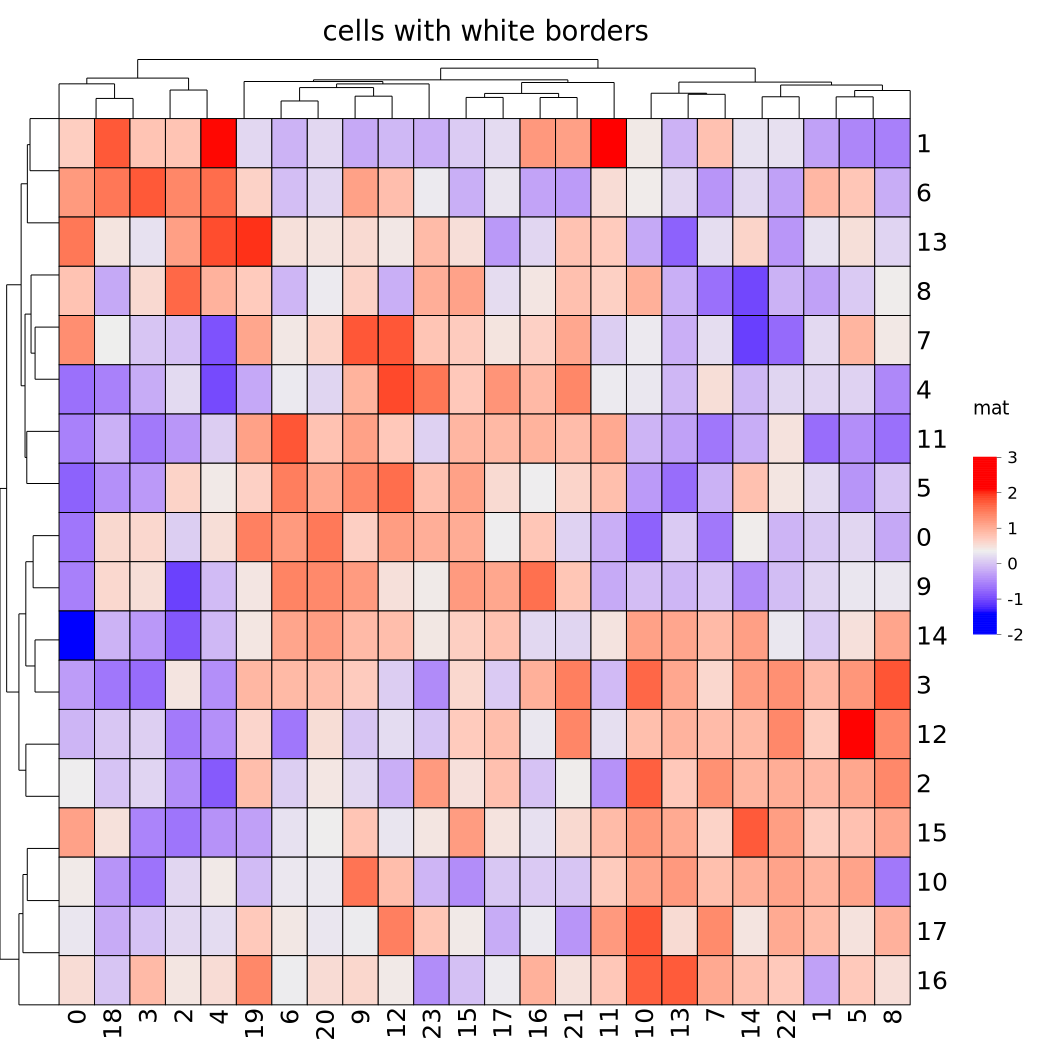

In [24]:
ht = Heatmap(mat.values, name="mat",
             rect_gp={"col": "white", "lwd": 2},
             column_title="cells with white borders")
ht.draw()

## Discrete Matrix

If the matrix contains discrete values, provide colors as a dict mapping values to colors. Clustering is turned off by default for character matrices.

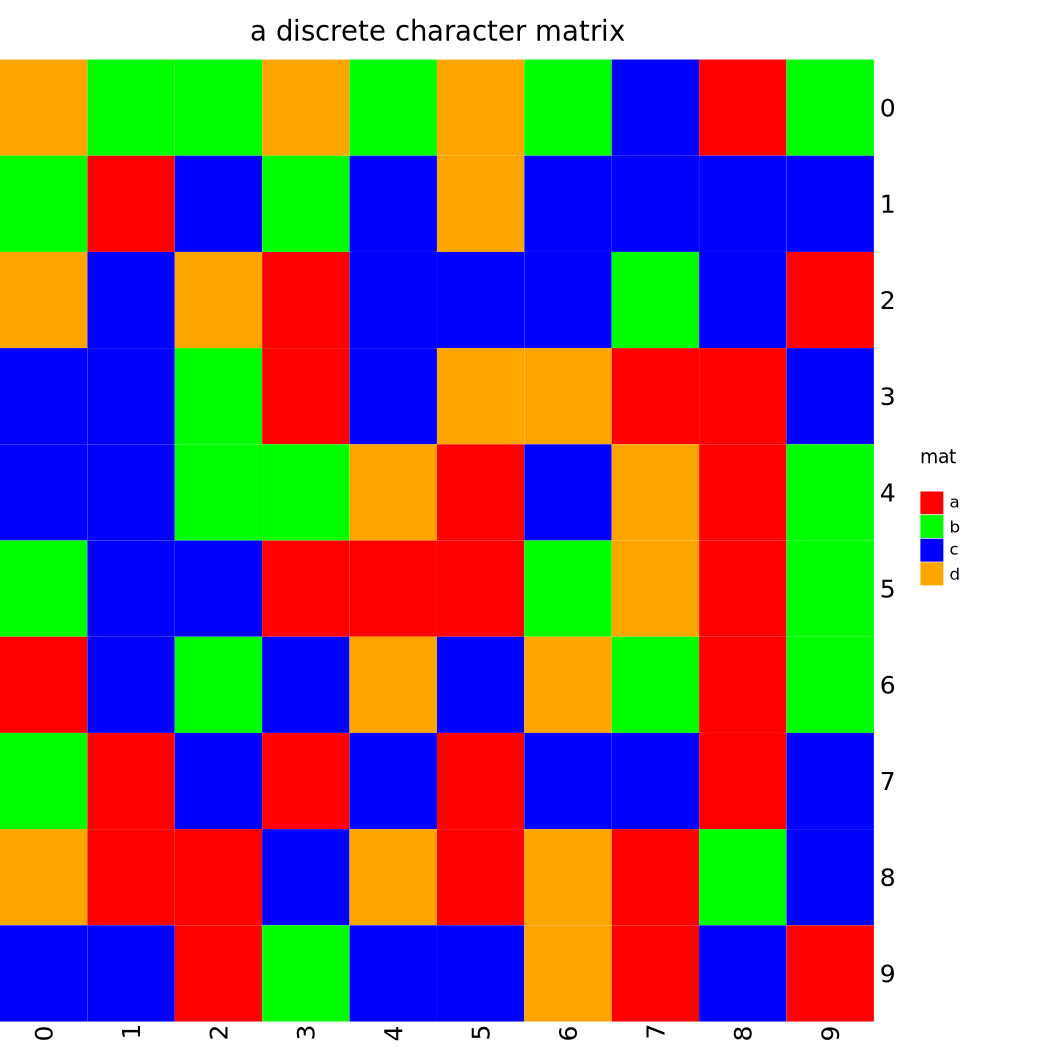

In [25]:
discrete_mat = np.random.choice(["a", "b", "c", "d"], size=(10, 10))
colors = {"a": "red", "b": "green", "c": "blue", "d": "orange"}

ht = Heatmap(discrete_mat, name="mat", col=colors,
             column_title="a discrete character matrix")
ht.draw()

## Global Options with `ht_opt`

Some parameters can be set globally via `ht_opt` so they apply to all subsequent heatmaps. Reset with `ht_opt(RESET=True)`.

In [26]:
# Example: change the default heatmap legend side
# ht_opt["heatmap_legend_side"] = "left"
# ... draw heatmaps ...
# ht_opt(RESET=True)  # reset when done
print("ht_opt is available for global configuration.")

ht_opt is available for global configuration.


## Summary

This tutorial covered the core functionality of a single heatmap:

- Basic construction with `Heatmap(mat, name=...)`
- Color mapping with `color_ramp2`
- Clustering on/off, distance and method options
- Manual row/column ordering
- Row/column splitting by k-means or categorical variables
- Titles and dimension name customization
- `cell_fun` for per-cell custom graphics
- Rasterization for large matrices
- NA handling with `na_col`
- Discrete matrix support